In [32]:
# Instala/actualiza pip y herramientas de empaquetado, y luego instala el paquete en modo editable
# Esto permite importar el paquete como `rtd_calibration_vgp` sin modificar sys.path
%pip install --upgrade pip setuptools wheel --quiet

# Instala dependencias y el paquete en modo editable desde la raíz del repo
%pip install -e ../.. --quiet

# Mostrar la versión de pip utilizada (opcional)
import pip
print('pip version:', pip.__version__)

# Si la instalación fue exitosa, podrás importar `rtd_calibration_vgp` desde el kernel.
# Nota: si instalas desde una ruta distinta, ajusta la llamada a pip arriba.

Note: you may need to restart the kernel to use updated packages.
  DEPRECATION: Legacy editable install of rtd_calibration_vgp==0.1.0 from file:///Users/vicky/Desktop/rtd-calibration-ana (setup.py develop) is deprecated. pip 25.3 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  DEPRECATION: Legacy editable install of rtd_calibration_vgp==0.1.0 from file:///Users/vicky/Desktop/rtd-calibration-ana (setup.py develop) is deprecated. pip 25.3 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings ed

In [ ]:
# Importar el paquete instalado en modo editable
from rtd_calibration_vgp.logfile import Logfile  # desde RTD_Calibration_VGP/src/logfile.py
from rtd_calibration_vgp.run import Run  # desde RTD_Calibration_VGP/src/run.py
from pathlib import Path
import pandas as pd

# Leer el logfile desde la carpeta data del repositorio (ruta relativa desde el notebook)
repo_root = Path('..').resolve()  # notebooks/.. -> RTD_Calibration_VGP
logfile_path = (repo_root / 'data' / 'LogFile.csv').resolve()
logfiles = Logfile(filepath=str(logfile_path))  # Esto lee el archivo CSV
logfile_df = logfiles.log_file  # Obtener el DataFrame cargado

# Ver los datos cargados del logfile
print("Logfile cargado:")
print(logfile_df.head())  # Mostrar las primeras filas del DataFrame




RuntimeError: An error occurred while reading the log file: [Errno 2] No such file or directory: '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/RTD_Calibration_VGP/data/LogFile.csv'

In [24]:
# 1. Cargar el logfile usando la clase LogFile (ya cargado en la celda anterior)
# Nota: `logfile_df` ya fue definido en la celda 1 como la ruta absoluta al archivo en data/LogFile.csv

# Ver los datos cargados del logfile (opcional)
# print(logfile_df.head())

# 2. Nombre del archivo de temperatura que quieres procesar
filename = "20250924_ln2_r48177_r49264_58374-58398_3"

# 1. Crear una instancia de la clase Run
run = Run(filename=filename, logfile=logfile_df)

###SON FUNCIONES QUE ESTÁN EN EL INIT Y SE REALIZAN DIRECTAMENTE AL CREAR LA INSTANCIA
# 2. Cargar el archivo de temperatura
#run.load_temperature_file()
#run.filter_faulty_channels()
# 3. Asociar los sensores con los canales de temperatura
#run.associate_sensors()

# 4. Imprimir el DataFrame con los datos procesados
print("Datos de temperatura con IDs de sensores asociados:")
print(run.temperature_data.head())  # Aquí accedes directamente al atributo de la instancia


Archivo de temperatura encontrado: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_59/20250924_ln2_r48177_r49264_58374-58398_3.txt (buscado en: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files)
Valores NaN (contador): 0
Empty DataFrame
Columns: [datetime, channel, value]
Index: []
Archivo de temperatura procesado correctamente: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/RTD_Calibs/CalSetN_59/20250924_ln2_r48177_r49264_58374-58398_3.txt
No se detectaron canales defectuosos.
Valores de sensores extraídos (antes de filtrado y conversión): [58374. 58400. 58399. 58371. 58373. 58372. 58366. 58367. 58401. 58375.
 58370. 58398. 48177. 49264.]
IDs de sensores después de la conversión: ['58374', '58400', '58399', '58371', '58373', '58372', '58366', '58367', '58401', '58375', '58370', '58398', '48177', '49264']
Asociación de canales con IDs de sensores:
channel_1: Sen

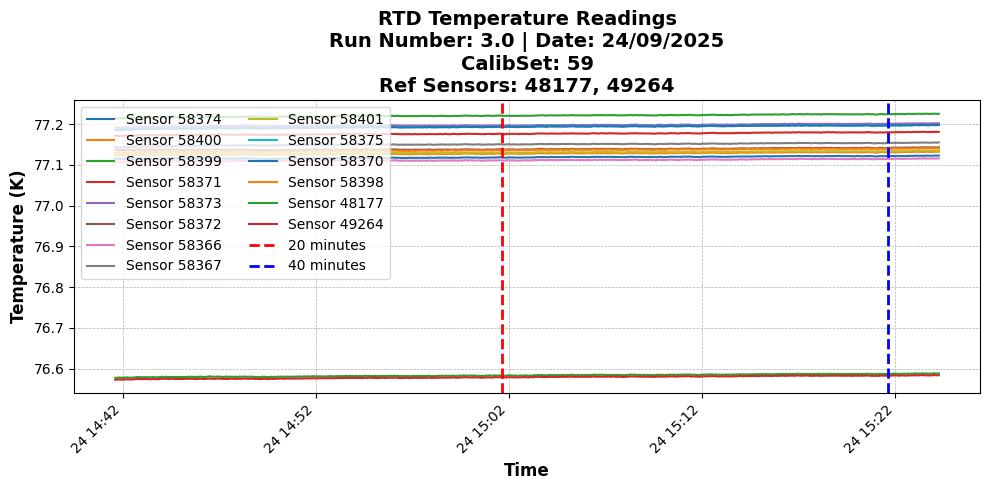

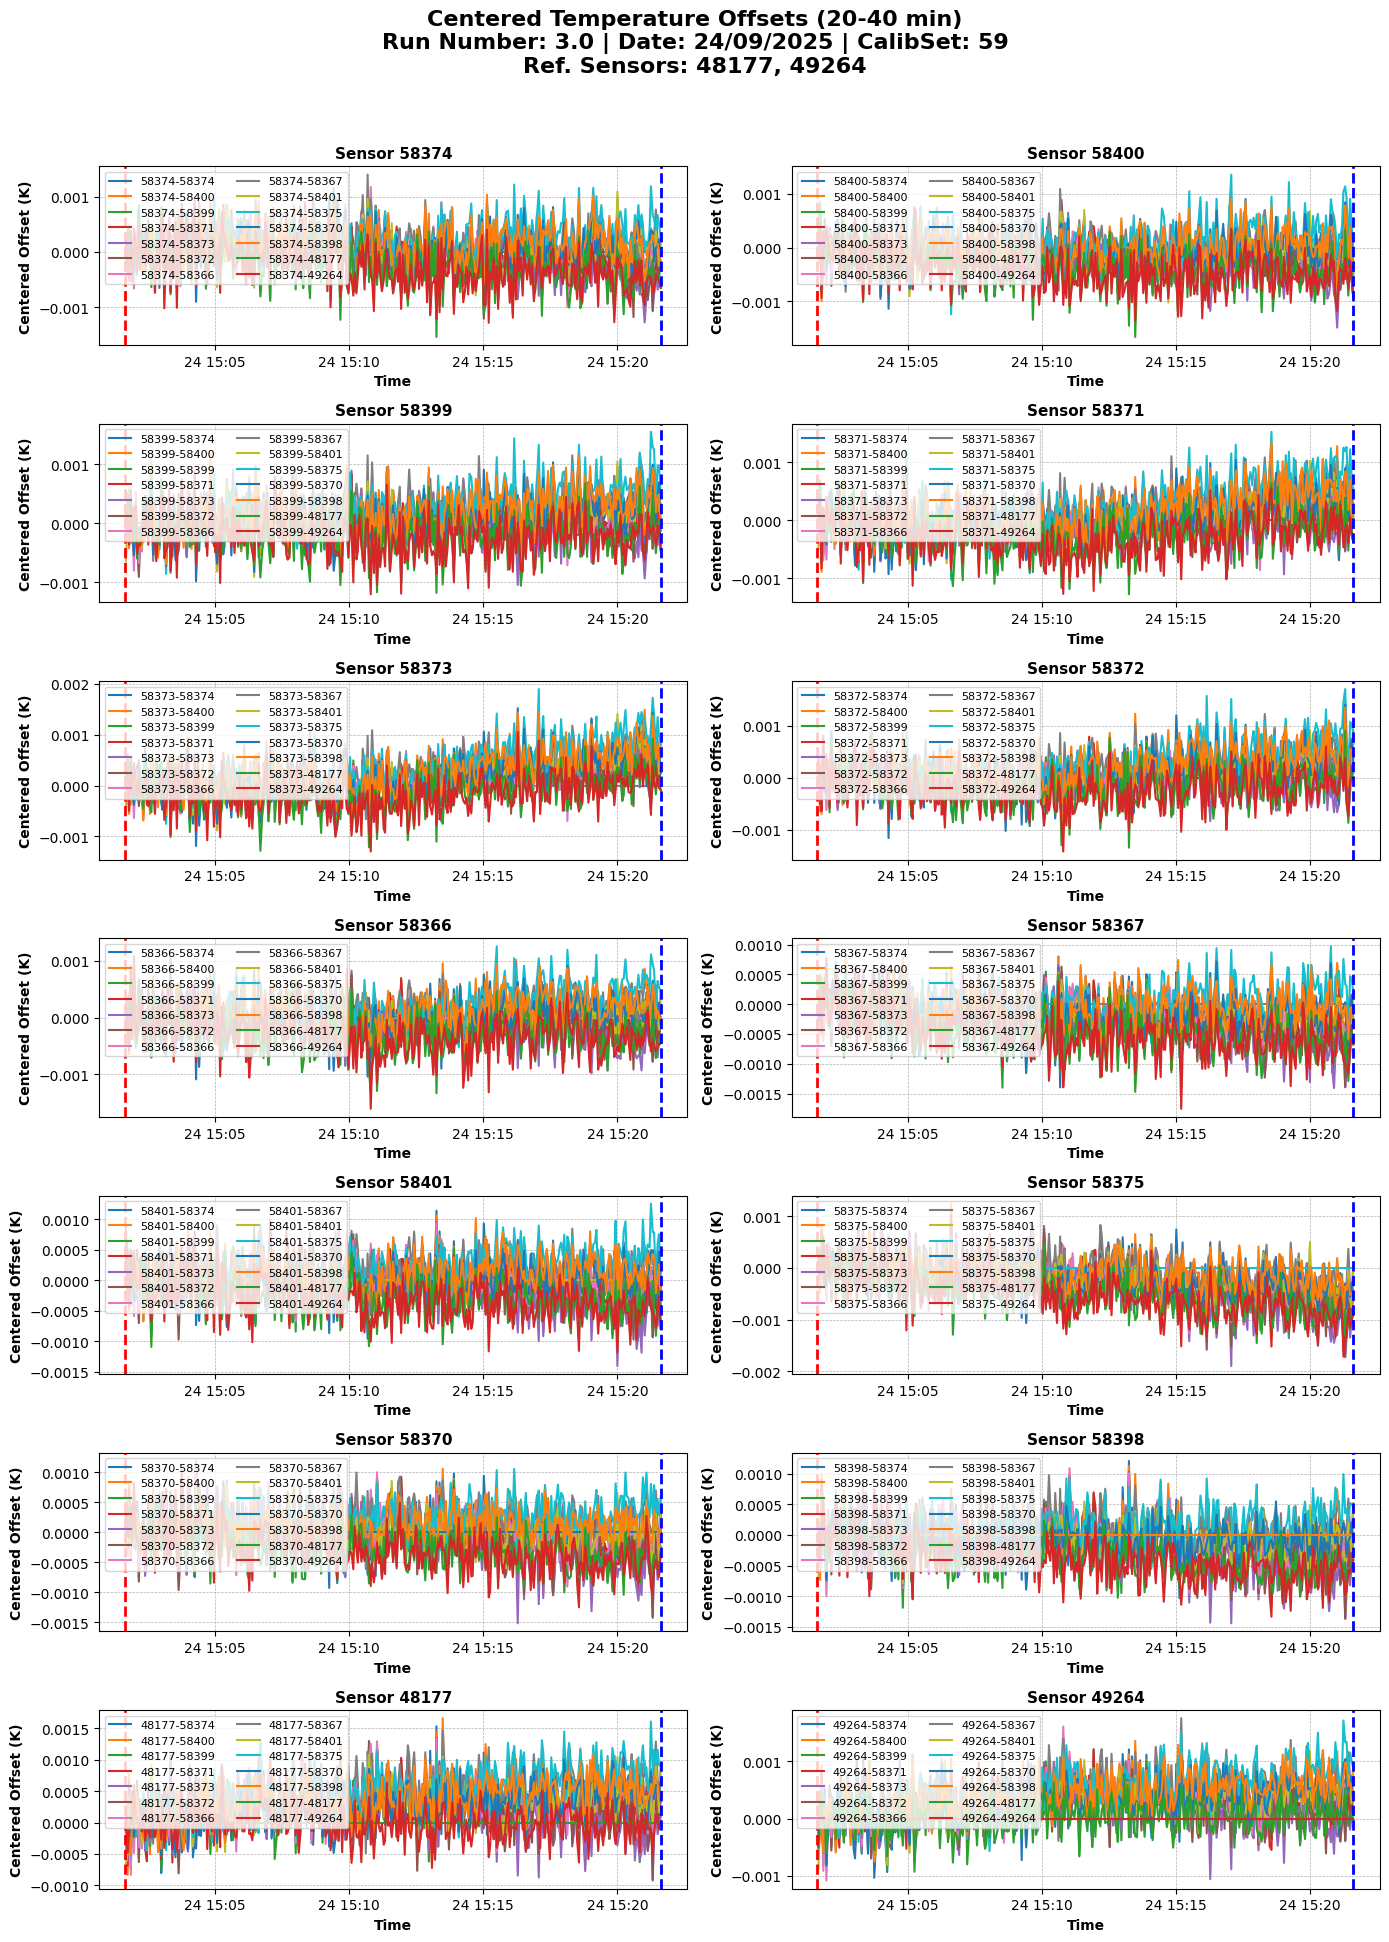

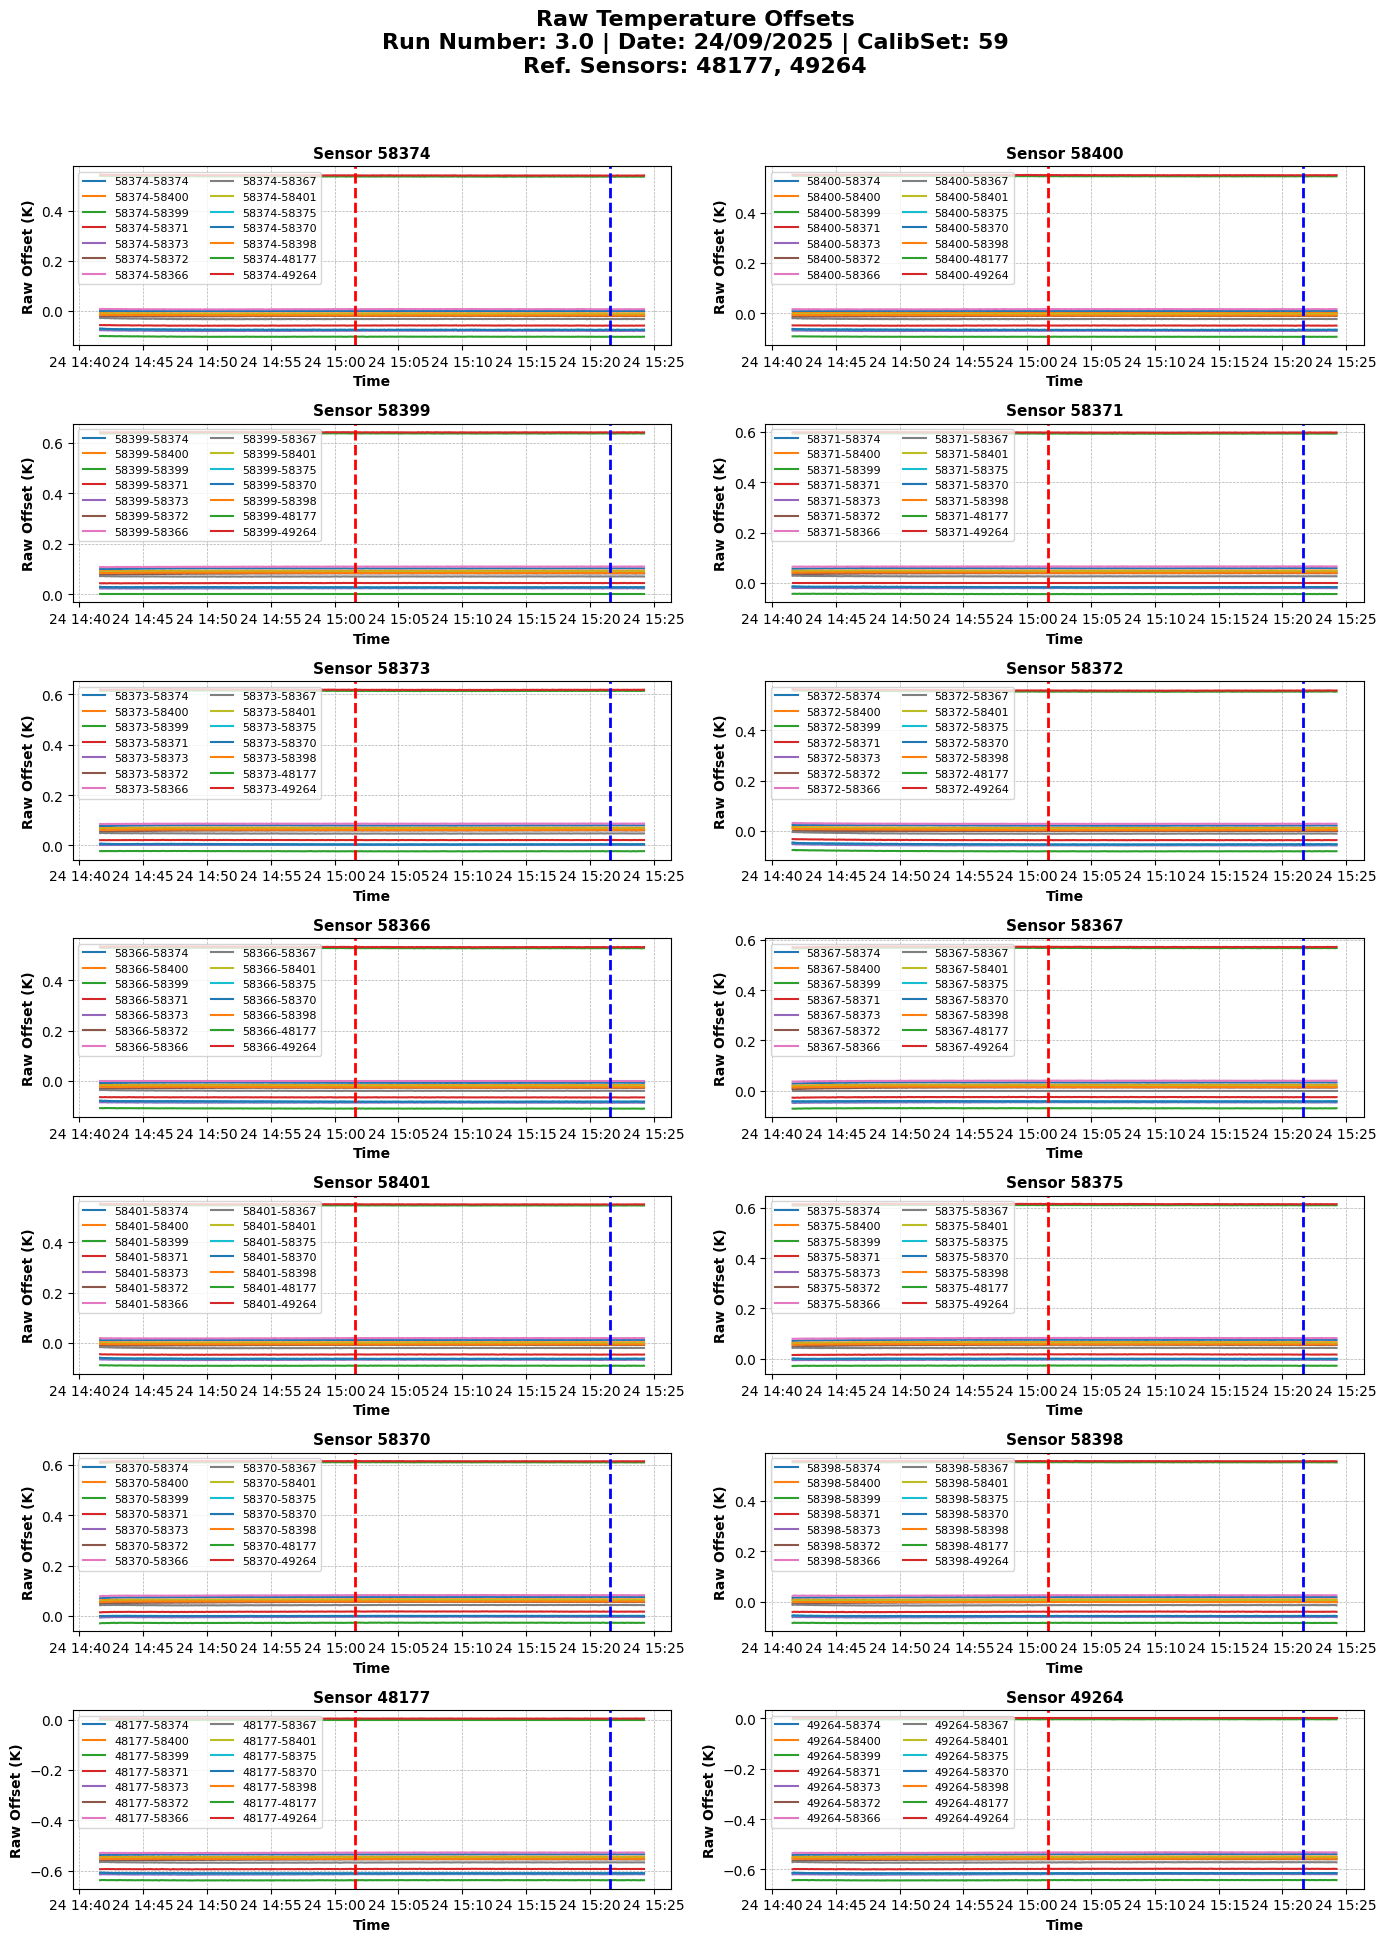

Plots saved in ./Plots/
Gráficos generados y guardados en: ./Plots/


In [25]:
output_dir = "./Plots/"

run.save_control_plots(output_dir=output_dir)

print(f"Gráficos generados y guardados en: {output_dir}")

In [26]:
# Calcular offsets
offsets_df = run.offsets()
#print("\nMatriz de Offsets (media entre sensores):")
print(offsets_df)

# Calcular errores (RMS)
errors_df = run.stat_err_offsets()
#print("\nErrores RMS de Offsets:")
print(errors_df)

Offsets medios calculados para los últimos 20 minutos del run.
          58374     58400     58399     58371     58373     58372     58366  \
58374  0.000000 -0.009253 -0.102559 -0.057966 -0.078758 -0.019697  0.007225   
58400  0.009253  0.000000 -0.093307 -0.048713 -0.069505 -0.010444  0.016478   
58399  0.102559  0.093307  0.000000  0.044593  0.023801  0.082862  0.109785   
58371  0.057966  0.048713 -0.044593  0.000000 -0.020792  0.038269  0.065191   
58373  0.078758  0.069505 -0.023801  0.020792  0.000000  0.059061  0.085984   
58372  0.019697  0.010444 -0.082862 -0.038269 -0.059061  0.000000  0.026923   
58366 -0.007225 -0.016478 -0.109785 -0.065191 -0.085984 -0.026923  0.000000   
58367  0.031985  0.022732 -0.070575 -0.025981 -0.046774  0.012287  0.039210   
58401  0.011888  0.002635 -0.090671 -0.046078 -0.066870 -0.007809  0.019113   
58375  0.075347  0.066094 -0.027213  0.017381 -0.003412  0.055649  0.082572   
58370  0.075243  0.065990 -0.027316  0.017277 -0.003515  0.055546  0

Gráfico guardado en: ./Plots/20250924_ln2_r48177_r49264_58374-58398_3_rms_vs_time.png


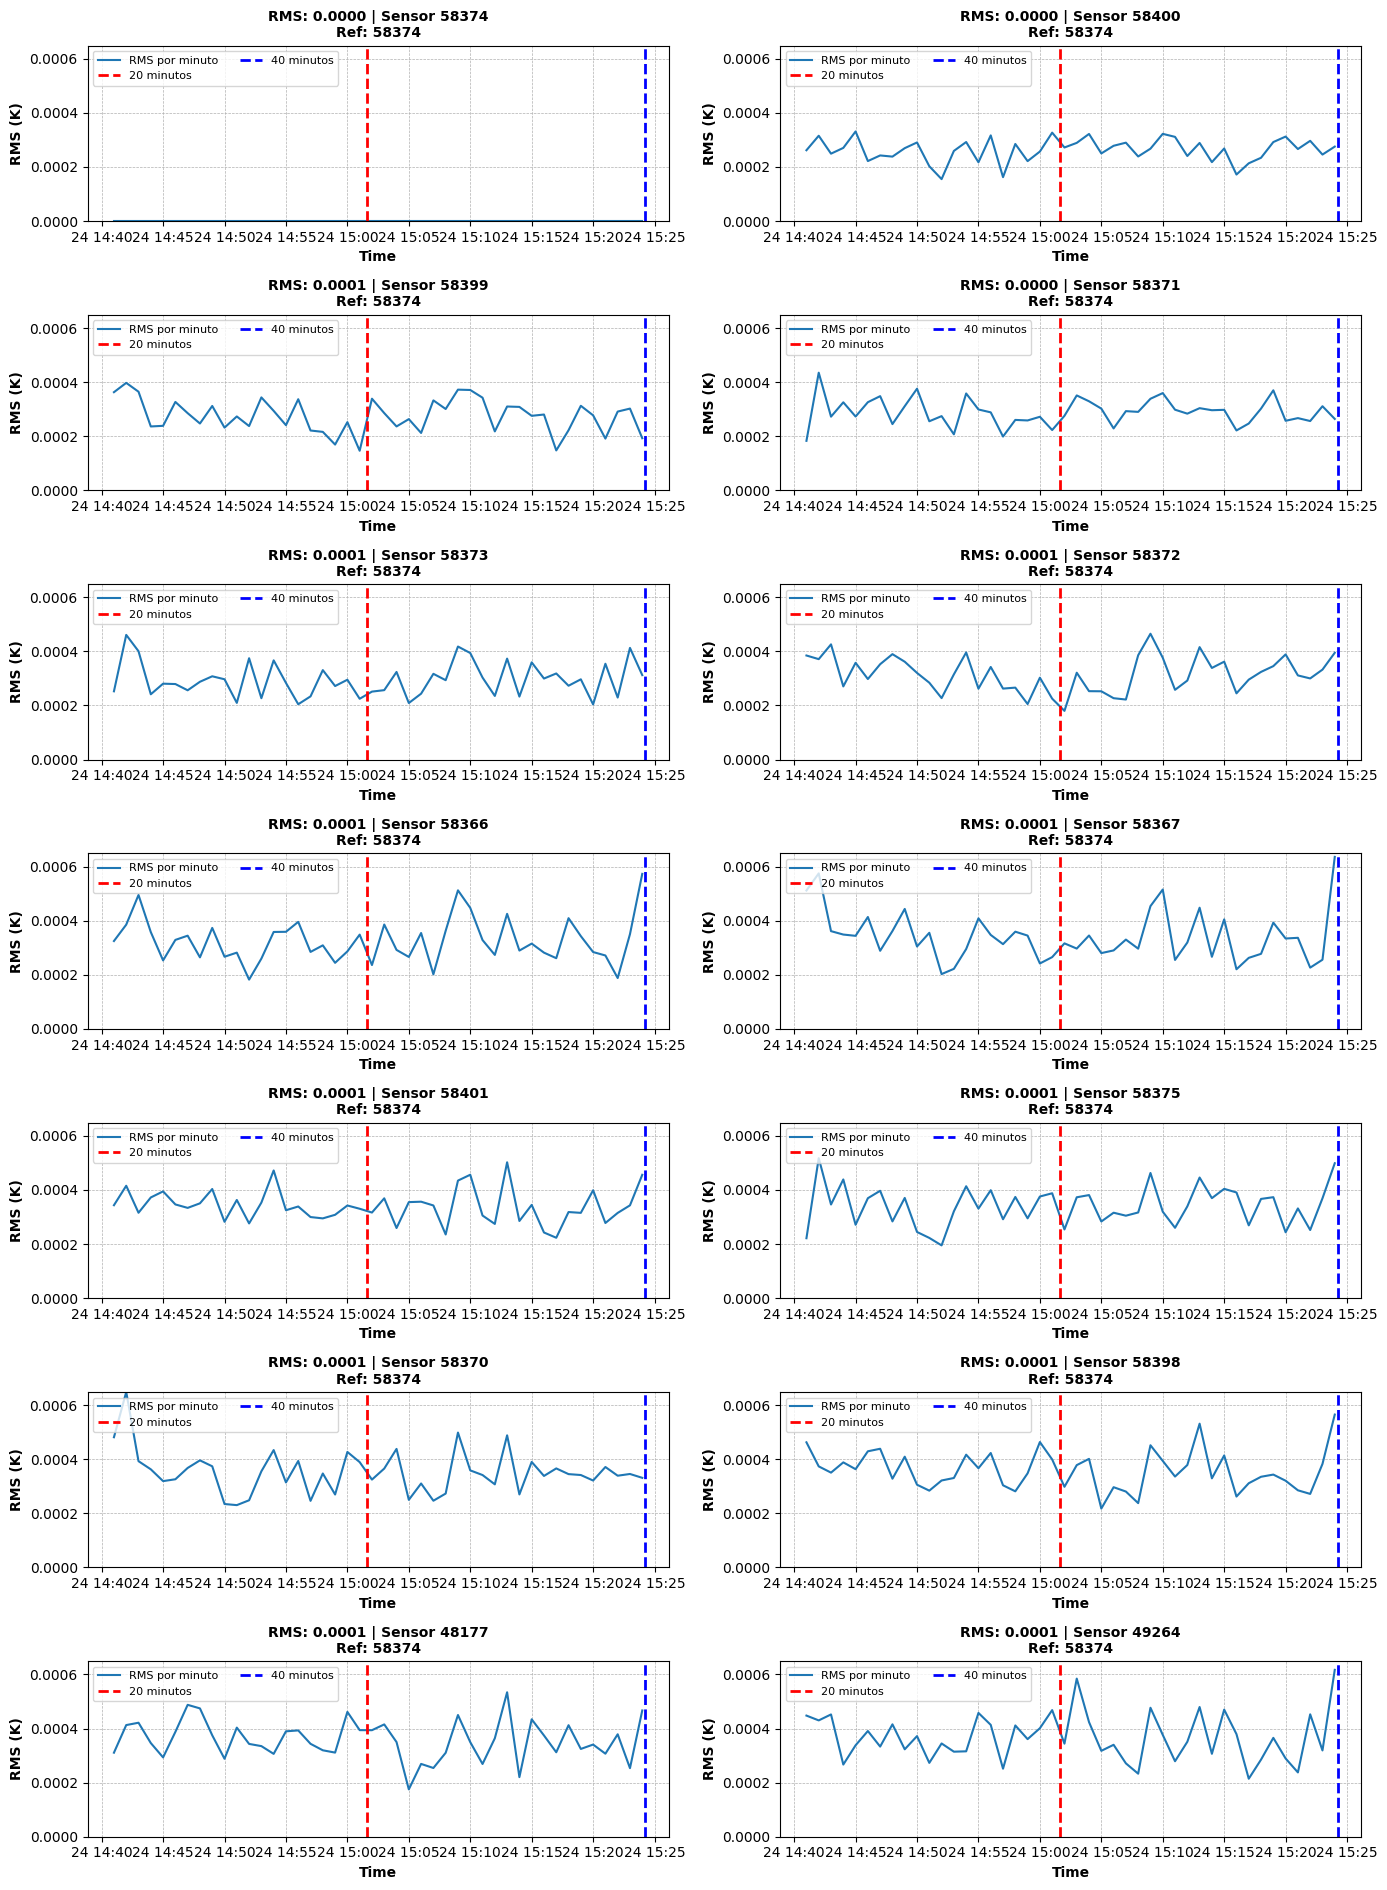

In [27]:
run.plot_rms_vs_time(output_dir= "./Plots/")